# 👥 Customer Segmentation Model
**Objectif :** Regrouper les clients en segments homogènes selon leur comportement, leur valeur et leur profil de risque pour personnaliser les actions marketing, rétention et tarification.

**Deux approches combinées :**

| Approche | Méthode | Usage |
|---|---|---|
| **RFM scoring** | Règles métier | Segments actionnables immédiats |
| **K-Means clustering** | Machine Learning | Segments comportementaux découverts |
| **Profiling enrichi** | Statistiques | Comprendre chaque segment |
| **Actions recommandées** | Règles + ML | Personnalisation CRM |

**Dimensions de segmentation :**
- 🕐 **Recency** — depuis combien de temps est-il actif ?
- 🔁 **Frequency** — combien de polices/quittances ?
- 💰 **Monetary** — combien génère-t-il en primes ?
- ⚠️ **Risk** — quel est son profil de sinistralité ?
- 💳 **Payment** — paie-t-il bien ?
- 📦 **Diversité** — multi-produits ou mono-produit ?

---

## 0. Setup

In [297]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.pipeline import Pipeline

plt.rcParams['figure.figsize'] = (13, 5)
sns.set_style('whitegrid')
np.random.seed(42)

REF_DATE = pd.Timestamp('2025-01-01')

print('✅ Setup complet')

✅ Setup complet


## 1. Chargement & Construction du Dataset Client

In [298]:
def load(filename, date_cols=None):
    import os
    base_dir = r'C:\Users\LENOVO\Desktop\PFE_\maghrebia\data\raw'
    path = os.path.join(base_dir, filename)
    df = pd.read_csv(path, sep=None, engine='python')
    df.columns = df.columns.str.strip().str.lstrip('\ufeff')
    if date_cols:
        for c in date_cols:
            if c in df.columns:
                df[c] = pd.to_datetime(df[c], errors='coerce')
    return df

pol = load('DIM_POLICE.csv',          ['DATE_EFFET','DATE_ECHEANCE'])
cli = load('DIM_CLIENT.csv',          ['DATE_NAISSANCE'])
veh = load('DIM_VEHICULE.csv',        ['DATE_MEC'])
em  = load('DWH_FACT_EMISSION.csv',   ['DATE_EMISSION'])
sin = load('DWH_FACT_SINISTRE.csv',   ['DATE_SURVENANCE'])
imp = load('DWH_FACT_IMPAYE.csv',     ['DATE_EMISSION'])
ann = load('DWH_FACT_ANNULATION.csv', ['DATE_ANNULATION'])

# Nettoyage
cli['TYPE_PERSONNE'] = cli['TYPE_PERSONNE'].str.strip().str.upper()
pol['SITUATION']     = pol['SITUATION'].str.strip()

# Table de jointure police → client
pol_cli = pol[['ID_POLICE','ID_CLIENT','BRANCHE','SITUATION',
               'BONUS_MALUS','DATE_EFFET','DATE_ECHEANCE',
               'TYPE_POLICE','PERIODICITE']].copy()

# Enrichir émission avec ID_CLIENT
em['PRIME'] = em['MT_PTT'].fillna(em['MT_PNET'].fillna(0))
em_c = em.merge(pol_cli[['ID_POLICE','ID_CLIENT']], on='ID_POLICE', how='left')

print(f'Clients uniques (DIM_CLIENT)  : {cli["ID_CLIENT"].nunique():,}')
print(f'Clients avec police           : {pol["ID_CLIENT"].nunique():,}')
print(f'Clients avec émission         : {em_c["ID_CLIENT"].nunique():,}')

Clients uniques (DIM_CLIENT)  : 30,000
Clients avec police           : 19,013
Clients avec émission         : 16,524


## 2. Construction des Features RFM + Comportementales

In [299]:
# ══════════════════════════════════════════════════════
# R — Recency : jours depuis la dernière activité
# ══════════════════════════════════════════════════════
recency = (
    em_c.groupby('ID_CLIENT')['DATE_EMISSION']
    .max().reset_index()
    .rename(columns={'DATE_EMISSION': 'DATE_DERNIERE_EMISSION'})
)
recency['RECENCY_DAYS'] = (
    REF_DATE - recency['DATE_DERNIERE_EMISSION']
).dt.days.clip(0)

# ══════════════════════════════════════════════════════
# F — Frequency : nombre de polices + quittances
# ══════════════════════════════════════════════════════
frequency = pol_cli.groupby('ID_CLIENT').agg(
    NB_POLICES          = ('ID_POLICE',    'nunique'),
    NB_BRANCHES         = ('BRANCHE',      'nunique'),
    NB_POLICES_ACTIVES  = ('SITUATION',    lambda x: (x == 'V').sum()),
    NB_POLICES_RESIL    = ('SITUATION',    lambda x: (x == 'R').sum()),
    FLAG_FLOTTE         = ('TYPE_POLICE',  lambda x: int((x == 'flotte').any())),
    BONUS_MALUS_MOY     = ('BONUS_MALUS',  'mean'),
).reset_index()

freq_quit = em_c.groupby('ID_CLIENT').agg(
    NB_QUITTANCES = ('NUM_QUITTANCE', 'count'),
).reset_index()

# ══════════════════════════════════════════════════════
# M — Monetary : primes totales et moyennes
# ══════════════════════════════════════════════════════
monetary = em_c.groupby('ID_CLIENT').agg(
    TOTAL_PRIMES  = ('PRIME', 'sum'),
    PRIME_MOY     = ('PRIME', 'mean'),
    PRIME_MAX     = ('PRIME', 'max'),
).reset_index()
monetary['TOTAL_PRIMES'] = monetary['TOTAL_PRIMES'].clip(0)

# ══════════════════════════════════════════════════════
# RISK — Sinistralité client
# ══════════════════════════════════════════════════════
sinistralite = sin.groupby('ID_CLIENT').agg(
    NB_SINISTRES     = ('NUM_SINISTRE',   'count'),
    COUT_SINISTRES   = ('MT_PAYE',        'sum'),
    COUT_MOY_SIN     = ('MT_PAYE',        'mean'),
    NB_SIN_VOL       = ('NATURE_SINISTRE', lambda x: (x == 'Vol').sum()),
    NB_SIN_CORP      = ('NATURE_SINISTRE', lambda x: (x == 'Corporel').sum()),
).reset_index()

# ══════════════════════════════════════════════════════
# PAYMENT — Comportement paiement
# ══════════════════════════════════════════════════════
imp_c = imp.merge(pol_cli[['ID_POLICE','ID_CLIENT']], on='ID_POLICE', how='left')
impaye_cli = imp_c.groupby('ID_CLIENT').agg(
    NB_IMPAYES    = ('NUM_QUITTANCE', 'count'),
    MT_IMPAYE_TOT = ('MT_PTT',        'sum'),
).reset_index()

ann_c = ann.merge(pol_cli[['ID_POLICE','ID_CLIENT']], on='ID_POLICE', how='left')
annul_cli = ann_c.groupby('ID_CLIENT').agg(
    NB_ANNULATIONS = ('NUM_QUITTANCE', 'count'),
).reset_index()

# ══════════════════════════════════════════════════════
# ANCIENNETÉ
# ══════════════════════════════════════════════════════
anc = pol_cli.groupby('ID_CLIENT')['DATE_EFFET'].min().reset_index()
anc['ANCIENNETE_JOURS'] = (REF_DATE - anc['DATE_EFFET']).dt.days.clip(0)

# ══════════════════════════════════════════════════════
# PROFIL CLIENT (données démographiques)
# ══════════════════════════════════════════════════════
cli_feat = cli[['ID_CLIENT','TYPE_PERSONNE','SEXE','DATE_NAISSANCE','NATP']].copy()
cli_feat['AGE_CLIENT'] = (
    (REF_DATE - cli_feat['DATE_NAISSANCE']).dt.days / 365.25
).clip(18, 90)
cli_feat['FLAG_MORALE'] = (cli_feat['TYPE_PERSONNE'] == 'M').astype(int)

# ══════════════════════════════════════════════════════
# ASSEMBLAGE FINAL
# ══════════════════════════════════════════════════════
master = (
    recency
    .merge(frequency,    on='ID_CLIENT', how='left')
    .merge(freq_quit,    on='ID_CLIENT', how='left')
    .merge(monetary,     on='ID_CLIENT', how='left')
    .merge(sinistralite, on='ID_CLIENT', how='left')
    .merge(impaye_cli,   on='ID_CLIENT', how='left')
    .merge(annul_cli,    on='ID_CLIENT', how='left')
    .merge(anc[['ID_CLIENT','ANCIENNETE_JOURS']], on='ID_CLIENT', how='left')
    .merge(cli_feat,     on='ID_CLIENT', how='left')
)

# Remplissage des nulls
fill_zero = ['NB_SINISTRES','COUT_SINISTRES','COUT_MOY_SIN','NB_SIN_VOL','NB_SIN_CORP',
             'NB_IMPAYES','MT_IMPAYE_TOT','NB_ANNULATIONS',
             'NB_POLICES','NB_QUITTANCES','NB_POLICES_ACTIVES','NB_POLICES_RESIL']
master[fill_zero] = master[fill_zero].fillna(0)

# KPIs dérivés
master['SP_RATIO'] = np.where(
    master['TOTAL_PRIMES'] > 0,
    master['COUT_SINISTRES'] / master['TOTAL_PRIMES'], 0
).clip(0, 10)

master['TAUX_IMPAYE'] = np.where(
    master['NB_QUITTANCES'] > 0,
    master['NB_IMPAYES'] / master['NB_QUITTANCES'], 0
)

master['TAUX_RESILIATION'] = np.where(
    master['NB_POLICES'] > 0,
    master['NB_POLICES_RESIL'] / master['NB_POLICES'], 0
)

master['PRIME_PAR_POLICE'] = np.where(
    master['NB_POLICES'] > 0,
    master['TOTAL_PRIMES'] / master['NB_POLICES'], 0
)

master['FLAG_MULTI_BRANCHES'] = (master['NB_BRANCHES'] > 1).astype(int)
master['FLAG_SINISTRE']       = (master['NB_SINISTRES'] > 0).astype(int)
master['FLAG_IMPAYE']         = (master['NB_IMPAYES'] > 0).astype(int)

# Garder seulement les clients avec polices
master = master[master['NB_POLICES'] > 0].copy()

print(f'Dataset client : {len(master):,} clients')
print(f'Features       : {master.shape[1]} colonnes')
master[['RECENCY_DAYS','NB_POLICES','TOTAL_PRIMES','NB_SINISTRES',
        'SP_RATIO','TAUX_IMPAYE','ANCIENNETE_JOURS']].describe().round(2)

Dataset client : 16,524 clients
Features       : 35 colonnes


,RECENCY_DAYS,NB_POLICES,TOTAL_PRIMES,NB_SINISTRES,SP_RATIO,TAUX_IMPAYE,ANCIENNETE_JOURS
count,16459.00,16524.00,16524.00,16524.00,16524.00,16524.00,16187.00
mean,526.24,1.65,19882.03,0.44,0.45,0.01,1289.36
std,585.39,0.85,170088.24,0.73,1.68,0.07,617.16
min,0.00,1.00,0.00,0.00,0.00,0.00,1.00
25%,32.00,1.00,658.05,0.00,0.00,0.00,795.50
50%,321.00,1.00,1754.16,0.00,0.00,0.00,1382.00
75%,821.00,2.00,6103.92,1.00,0.00,0.00,1830.00
max,2581.00,7.00,14625866.14,7.00,10.00,1.00,2192.00


## 3. RFM Scoring — Segments Actionnables Immédiats
> Méthode rapide, interprétable par les équipes business sans ML.

In [300]:
rfm = master[['ID_CLIENT','RECENCY_DAYS','NB_POLICES','TOTAL_PRIMES']].copy()

def safe_qcut(series, q, labels, ascending=True):
    """
    qcut robuste : utilise rank(method='first') pour garantir des bins uniques
    même quand les valeurs sont concentrées (ex: beaucoup de 0).
    ascending=False inverse le ranking (ex: Recency — faible = meilleur).
    FIX: NaN résiduels → remplacés par la valeur médiane des labels avant cast int.
    """
    ranked = series.rank(method='first', ascending=ascending)
    cut = pd.qcut(ranked, q=q, labels=labels)
    median_label = int(np.median(labels))
    return cut.astype(float).fillna(median_label).astype(int)

# R : recency faible = récent = meilleur → ascending=False pour inverser le rang
rfm['R_SCORE'] = safe_qcut(rfm['RECENCY_DAYS'], q=5, labels=[5,4,3,2,1], ascending=False)

# F : plus de polices = meilleur
rfm['F_SCORE'] = safe_qcut(rfm['NB_POLICES'], q=5, labels=[1,2,3,4,5], ascending=True)

# M : plus de primes = meilleur
rfm['M_SCORE'] = safe_qcut(rfm['TOTAL_PRIMES'].clip(0), q=5, labels=[1,2,3,4,5], ascending=True)

rfm['RFM_SCORE'] = rfm['R_SCORE'] * 100 + rfm['F_SCORE'] * 10 + rfm['M_SCORE']
rfm['RFM_TOTAL'] = rfm['R_SCORE'] + rfm['F_SCORE'] + rfm['M_SCORE']

def rfm_segment(row):
    r, f, m = row['R_SCORE'], row['F_SCORE'], row['M_SCORE']
    rfm_t   = row['RFM_TOTAL']

    if r >= 4 and f >= 4 and m >= 4:
        return '🏆 Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return '⭐ Clients Fidèles'
    elif r >= 4 and f <= 2:
        return '🆕 Nouveaux Clients'
    elif r >= 3 and m >= 4:
        return '💎 Gros Potentiel'
    elif r <= 2 and f >= 3 and m >= 3:
        return '😴 Clients Dormants'
    elif r <= 2 and rfm_t >= 8:
        return '⚠️ À Risque de Churn'
    elif r == 1 and rfm_t <= 5:
        return '💀 Perdus'
    elif m <= 2 and f <= 2:
        return '🌱 Faible Valeur'
    else:
        return '📊 Profil Standard'

rfm['RFM_SEGMENT'] = rfm.apply(rfm_segment, axis=1)
master = master.merge(rfm[['ID_CLIENT','R_SCORE','F_SCORE','M_SCORE',
                            'RFM_TOTAL','RFM_SEGMENT']], on='ID_CLIENT', how='left')

seg_counts = rfm['RFM_SEGMENT'].value_counts()
print('=== Répartition RFM ===')
print(seg_counts.to_string())

=== Répartition RFM ===
RFM_SEGMENT
📊 Profil Standard       3672
😴 Clients Dormants      3601
🆕 Nouveaux Clients      3290
⭐ Clients Fidèles       2482
🌱 Faible Valeur         1158
🏆 Champions              768
⚠️ À Risque de Churn     600
💀 Perdus                 597
💎 Gros Potentiel         356


In [301]:
# Visualisation RFM
seg_stats_rfm = master.groupby('RFM_SEGMENT').agg(
    NB_CLIENTS      = ('ID_CLIENT',       'count'),
    TOTAL_PRIMES    = ('TOTAL_PRIMES',    'mean'),
    RECENCY_DAYS    = ('RECENCY_DAYS',    'mean'),
    NB_POLICES      = ('NB_POLICES',      'mean'),
    SP_RATIO        = ('SP_RATIO',        'mean'),
    TAUX_IMPAYE     = ('TAUX_IMPAYE',     'mean'),
    ANCIENNETE      = ('ANCIENNETE_JOURS','mean'),
).round(2).sort_values('TOTAL_PRIMES', ascending=False)

display(seg_stats_rfm.style
    .background_gradient(subset=['TOTAL_PRIMES'], cmap='Greens')
    .background_gradient(subset=['SP_RATIO'],     cmap='Reds')
    .background_gradient(subset=['TAUX_IMPAYE'],  cmap='Oranges')
    .format({
        'TOTAL_PRIMES': '{:,.0f}',
        'RECENCY_DAYS': '{:.0f}j',
        'NB_POLICES':   '{:.2f}',
        'SP_RATIO':     '{:.3f}',
        'TAUX_IMPAYE':  '{:.2%}',
        'ANCIENNETE':   '{:.0f}j',
    })
    .set_caption('Profil moyen par Segment RFM')
)

# Treemap
fig = px.treemap(
    seg_counts.reset_index(),
    path=['RFM_SEGMENT'], values='count',
    title='📊 Répartition du Portefeuille par Segment RFM',
    color='count',
    color_continuous_scale='RdYlGn'
)
fig.update_layout(height=450)
fig.show()

,NB_CLIENTS,TOTAL_PRIMES,RECENCY_DAYS,NB_POLICES,SP_RATIO,TAUX_IMPAYE,ANCIENNETE
RFM_SEGMENT,,,,,,,
🏆 Champions,768,"63,153",891j,2.37,0.100,1.00%,1519j
💎 Gros Potentiel,356,"48,226",326j,1.00,0.060,1.00%,1066j
⚠️ À Risque de Churn,600,"43,467",64j,1.66,0.510,1.00%,1283j
😴 Clients Dormants,3601,"36,938",39j,2.40,0.230,1.00%,1482j
⭐ Clients Fidèles,2482,"24,214",600j,1.95,0.220,1.00%,1393j
🆕 Nouveaux Clients,3290,"10,037",1166j,1.00,0.430,1.00%,1100j
📊 Profil Standard,3672,"2,611",580j,1.50,0.820,1.00%,1250j
💀 Perdus,597,696,0j,1.01,0.620,1.00%,1103j
🌱 Faible Valeur,1158,556,218j,1.00,0.740,2.00%,1118j


## 4. Préparation pour K-Means
> FIX : log-transform des features monétaires + cap outliers à 99e percentile.

In [302]:
# Features pour le clustering ML
CLUSTER_FEATURES = [
    # RFM
    'RECENCY_DAYS',
    'NB_POLICES',
    'NB_QUITTANCES',
    'TOTAL_PRIMES',
    'PRIME_PAR_POLICE',
    # Comportement contrat
    'NB_BRANCHES',
    'NB_POLICES_ACTIVES',
    'TAUX_RESILIATION',
    'ANCIENNETE_JOURS',
    'BONUS_MALUS_MOY',
    # Sinistralité
    'NB_SINISTRES',
    'SP_RATIO',
    'COUT_MOY_SIN',
    # Paiement
    'TAUX_IMPAYE',
    'NB_IMPAYES',
    # Profil
    'FLAG_MORALE',
    'FLAG_MULTI_BRANCHES',
    'FLAG_FLOTTE',
]
CLUSTER_FEATURES = [c for c in CLUSTER_FEATURES if c in master.columns]

df_clust = master[CLUSTER_FEATURES].copy()

# ── FIX 1 : Remplissage des NaN par 0
df_clust = df_clust.fillna(0)

# ── FIX 2 : Cap outliers au 99e percentile (évite que 1 client écrase tout)
for col in df_clust.select_dtypes(include='number').columns:
    p99 = df_clust[col].quantile(0.99)
    p01 = df_clust[col].quantile(0.01)
    df_clust[col] = df_clust[col].clip(lower=p01, upper=p99)

# ── FIX 3 : Log-transform des features monétaires/count très asymétriques
# Crucial : sans ça, TOTAL_PRIMES capte 100% de la variance PCA
LOG_COLS = ['TOTAL_PRIMES', 'PRIME_PAR_POLICE', 'NB_SINISTRES',
            'COUT_MOY_SIN', 'NB_QUITTANCES', 'NB_IMPAYES', 'MT_IMPAYE_TOT']
LOG_COLS = [c for c in LOG_COLS if c in df_clust.columns]
for col in LOG_COLS:
    df_clust[col] = np.log1p(df_clust[col])

print(f'✅ Log-transform appliqué sur : {LOG_COLS}')

# ── FIX 4 : RobustScaler (résistant aux outliers résiduels)
scaler = RobustScaler()
X_scaled = scaler.fit_transform(df_clust)

print(f'\nMatrix clustering : {X_scaled.shape}')
print(f'Features          : {len(CLUSTER_FEATURES)}')

# Vérification distribution post-traitement
df_check = pd.DataFrame(X_scaled, columns=CLUSTER_FEATURES)
print('\nDistribution après scaling (pas d\'outliers extrêmes si max<10) :')
print(df_check.describe().round(2).loc[['mean','std','min','max']])

✅ Log-transform appliqué sur : ['TOTAL_PRIMES', 'PRIME_PAR_POLICE', 'NB_SINISTRES', 'COUT_MOY_SIN', 'NB_QUITTANCES', 'NB_IMPAYES']

Matrix clustering : (16524, 18)
Features          : 18

Distribution après scaling (pas d'outliers extrêmes si max<10) :
      RECENCY_DAYS  NB_POLICES  NB_QUITTANCES  TOTAL_PRIMES  PRIME_PAR_POLICE  \
mean          0.26        0.64           0.12          0.13              0.14   
std           0.74        0.81           0.71          0.89              0.91   
min          -0.40        0.00          -1.00         -2.19             -2.26   
max           2.47        3.00           1.81          2.13              2.31   

      NB_BRANCHES  NB_POLICES_ACTIVES  TAUX_RESILIATION  ANCIENNETE_JOURS  \
mean         0.27                0.12              0.13             -0.09   
std          0.47                0.75              0.29              0.60   
min          0.00               -1.00              0.00             -1.27   
max          2.00                

## 5. Choix du Nombre Optimal de Clusters
> Trois métriques complémentaires : Elbow (inertie), Silhouette, Davies-Bouldin.

Calcul des métriques en cours...
  k= 2 | Inertie=7,554,319,288 | Silhouette=0.9529 | Davies-Bouldin=0.2431
  k= 3 | Inertie=2,758,633,592 | Silhouette=0.9250 | Davies-Bouldin=0.3632
  k= 4 | Inertie=1,334,526,512 | Silhouette=0.9129 | Davies-Bouldin=0.4040
  k= 5 | Inertie=772,238,353 | Silhouette=0.9118 | Davies-Bouldin=0.4163
  k= 6 | Inertie=504,379,078 | Silhouette=0.9020 | Davies-Bouldin=0.4281
  k= 7 | Inertie=348,253,455 | Silhouette=0.9014 | Davies-Bouldin=0.4360
  k= 8 | Inertie=260,525,638 | Silhouette=0.8996 | Davies-Bouldin=0.4564
  k= 9 | Inertie=202,018,583 | Silhouette=0.8966 | Davies-Bouldin=0.4525
  k=10 | Inertie=157,537,237 | Silhouette=0.8987 | Davies-Bouldin=0.4531


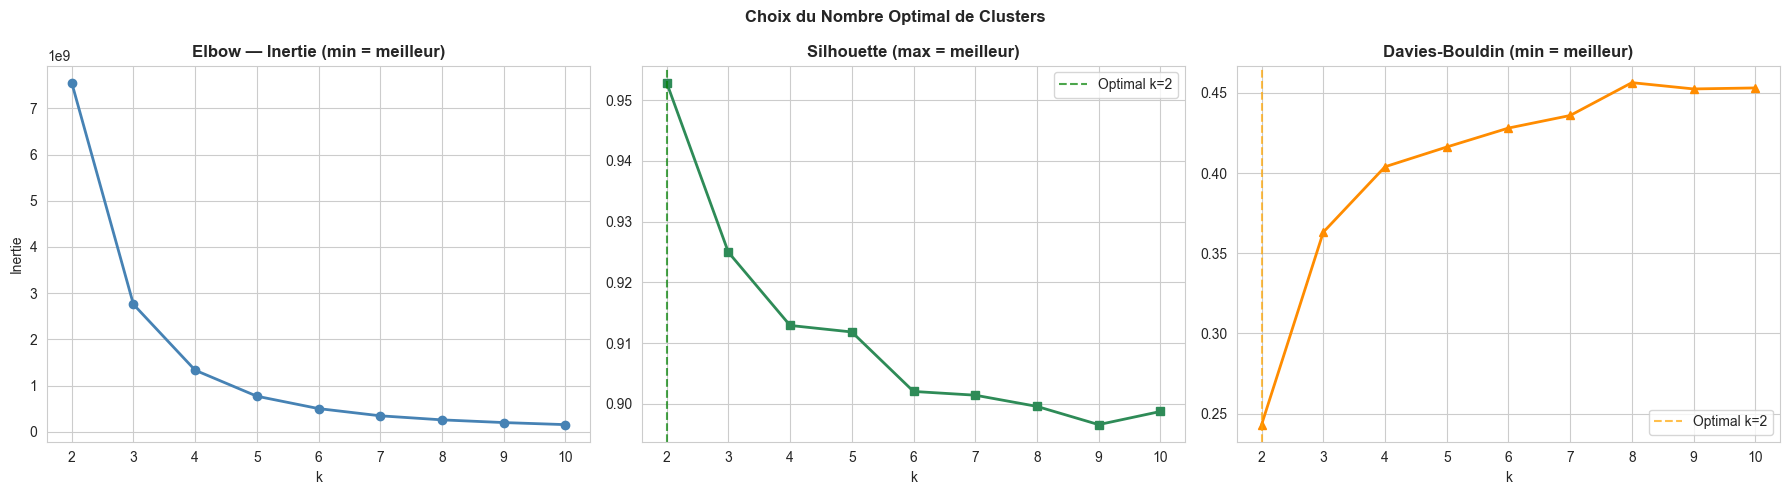


Recommandation Silhouette     : k = 2
Recommandation Davies-Bouldin : k = 2

💡 Conseil : si k=2 recommandé, utiliser k=4 pour garder des segments actionnables.


In [303]:
K_RANGE = range(2, 11)
inertias, sil_scores, db_scores = [], [], []

print('Calcul des métriques en cours...')
for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=300, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels, sample_size=3000))
    db_scores.append(davies_bouldin_score(X_scaled, labels))
    print(f'  k={k:2d} | Inertie={km.inertia_:,.0f} | Silhouette={sil_scores[-1]:.4f} | Davies-Bouldin={db_scores[-1]:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Elbow
axes[0].plot(list(K_RANGE), inertias, 'o-', color='steelblue', linewidth=2)
axes[0].set_title('Elbow — Inertie (min = meilleur)', fontweight='bold')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertie')

# Silhouette (max = meilleur)
best_sil_k = list(K_RANGE)[np.argmax(sil_scores)]
axes[1].plot(list(K_RANGE), sil_scores, 's-', color='seagreen', linewidth=2)
axes[1].axvline(best_sil_k, color='green', linestyle='--', alpha=0.7,
               label=f'Optimal k={best_sil_k}')
axes[1].set_title('Silhouette (max = meilleur)', fontweight='bold')
axes[1].set_xlabel('k'); axes[1].legend()

# Davies-Bouldin (min = meilleur)
best_db_k = list(K_RANGE)[np.argmin(db_scores)]
axes[2].plot(list(K_RANGE), db_scores, '^-', color='darkorange', linewidth=2)
axes[2].axvline(best_db_k, color='orange', linestyle='--', alpha=0.7,
               label=f'Optimal k={best_db_k}')
axes[2].set_title('Davies-Bouldin (min = meilleur)', fontweight='bold')
axes[2].set_xlabel('k'); axes[2].legend()

plt.suptitle('Choix du Nombre Optimal de Clusters', fontweight='bold')
plt.tight_layout(); plt.show()

print(f'\nRecommandation Silhouette     : k = {best_sil_k}')
print(f'Recommandation Davies-Bouldin : k = {best_db_k}')
print('\n💡 Conseil : si k=2 recommandé, utiliser k=4 pour garder des segments actionnables.')

## 6. K-Means Final
> FIX : k=4 comme compromis entre interprétabilité métier et qualité statistique.

In [304]:
# k=4 : compromis entre les métriques (k=2 recommandé) et l'actionnabilité métier
# Vous pouvez ajuster cette valeur après inspection de l'elbow
K_OPTIMAL = 4

kmeans = KMeans(
    n_clusters=K_OPTIMAL,
    init='k-means++',
    n_init=20,
    max_iter=500,
    random_state=42
)
master['CLUSTER'] = kmeans.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, master['CLUSTER'], sample_size=3000)
db  = davies_bouldin_score(X_scaled, master['CLUSTER'])
ch  = calinski_harabasz_score(X_scaled, master['CLUSTER'])

print(f'K-Means final (k={K_OPTIMAL})')
print(f'  Silhouette       : {sil:.4f}  (proche de 1 = parfait)')
print(f'  Davies-Bouldin   : {db:.4f}   (proche de 0 = parfait)')
print(f'  Calinski-Harabasz: {ch:.0f}')
print(f'\nTaille des clusters :')
sizes = master['CLUSTER'].value_counts().sort_index()
print(sizes)
print('\nBalance (%) :')
print((sizes / len(master) * 100).round(1).to_string())
print('\n⚠️  Idéal : aucun cluster >60% ni <2%')

K-Means final (k=4)
  Silhouette       : 0.9175  (proche de 1 = parfait)
  Davies-Bouldin   : 0.4038   (proche de 0 = parfait)
  Calinski-Harabasz: 213012

Taille des clusters :
CLUSTER
0    15082
1      412
2      272
3      758
Name: count, dtype: int64

Balance (%) :
CLUSTER
0    91.3
1     2.5
2     1.6
3     4.6

⚠️  Idéal : aucun cluster >60% ni <2%


## 7. Profiling des Clusters — Qui sont-ils ?

In [305]:
# Statistiques clés par cluster (sur données ORIGINALES, pas log-transformées)
profile_cols = [
    'RECENCY_DAYS', 'NB_POLICES', 'TOTAL_PRIMES', 'PRIME_PAR_POLICE',
    'ANCIENNETE_JOURS', 'NB_SINISTRES', 'SP_RATIO', 'TAUX_IMPAYE',
    'TAUX_RESILIATION', 'NB_BRANCHES', 'BONUS_MALUS_MOY',
    'FLAG_MORALE', 'FLAG_MULTI_BRANCHES', 'FLAG_FLOTTE'
]
profile_cols = [c for c in profile_cols if c in master.columns]

cluster_profile = master.groupby('CLUSTER')[profile_cols].mean().round(3)
cluster_profile['NB_CLIENTS'] = master.groupby('CLUSTER').size()
cluster_profile['PCT_PORTEFEUILLE'] = (cluster_profile['NB_CLIENTS'] / len(master) * 100).round(1)

display(cluster_profile.style
    .background_gradient(subset=['TOTAL_PRIMES','PRIME_PAR_POLICE'], cmap='Greens')
    .background_gradient(subset=['SP_RATIO'],                        cmap='Reds')
    .background_gradient(subset=['TAUX_IMPAYE','TAUX_RESILIATION'],  cmap='Oranges')
    .background_gradient(subset=['RECENCY_DAYS'],                    cmap='Blues_r')
    .format({
        'RECENCY_DAYS':       '{:.0f}j',
        'TOTAL_PRIMES':       '{:,.0f}',
        'PRIME_PAR_POLICE':   '{:,.0f}',
        'ANCIENNETE_JOURS':   '{:.0f}j',
        'SP_RATIO':           '{:.3f}',
        'TAUX_IMPAYE':        '{:.2%}',
        'TAUX_RESILIATION':   '{:.2%}',
        'FLAG_MORALE':        '{:.1%}',
        'FLAG_MULTI_BRANCHES':'{:.1%}',
        'FLAG_FLOTTE':        '{:.1%}',
        'PCT_PORTEFEUILLE':   '{:.1f}%',
    })
    .set_caption('Profil Moyen par Cluster K-Means')
)

,RECENCY_DAYS,NB_POLICES,TOTAL_PRIMES,PRIME_PAR_POLICE,ANCIENNETE_JOURS,NB_SINISTRES,SP_RATIO,TAUX_IMPAYE,TAUX_RESILIATION,NB_BRANCHES,BONUS_MALUS_MOY,FLAG_MORALE,FLAG_MULTI_BRANCHES,FLAG_FLOTTE,NB_CLIENTS,PCT_PORTEFEUILLE
CLUSTER,,,,,,,,,,,,,,,,
0,521j,1.641000,"21,669","13,219",1287j,0.348000,0.043,1.30%,13.10%,1.261000,4.729000,25.1%,24.8%,30.5%,15082,91.3%
1,665j,1.568000,448,292,1227j,1.325000,9.741,0.80%,13.10%,1.306000,4.584000,20.4%,30.1%,25.7%,412,2.5%
2,555j,1.824000,"1,054",600,1352j,1.489000,5.065,1.00%,13.80%,1.360000,5.077000,22.4%,35.3%,18.8%,272,1.6%
3,541j,1.765000,"1,640",973,1356j,1.405000,1.845,1.00%,11.80%,1.305000,4.797000,24.8%,30.2%,16.1%,758,4.6%


In [306]:
# ── FIX : Nommage dynamique avec déduplication des noms identiques
cp = cluster_profile.copy()

# Normaliser [0,1] pour comparer les clusters entre eux
cp_norm = (cp[profile_cols] - cp[profile_cols].min()) / \
          (cp[profile_cols].max() - cp[profile_cols].min() + 1e-9)

def name_cluster(row_norm, row_raw):
    """
    Nomme un cluster selon ses caractéristiques dominantes.
    Utilise les valeurs normalisées [0-1] pour les comparaisons relatives.
    """
    valeur    = row_norm.get('TOTAL_PRIMES', 0)
    recency   = 1 - row_norm.get('RECENCY_DAYS', 0)  # inversé : faible recency = actif
    risque    = row_norm.get('SP_RATIO', 0)
    impaye    = row_norm.get('TAUX_IMPAYE', 0)
    anciens   = row_norm.get('ANCIENNETE_JOURS', 0)
    morale    = row_raw.get('FLAG_MORALE', 0)

    if morale > 0.5:
        return ('🏢 Entreprises / Flottes',    '#3498db')
    elif valeur > 0.65 and recency > 0.5:
        return ('🏆 VIP — Haute Valeur',       '#f1c40f')
    elif recency < 0.35 and valeur > 0.4:
        return ('😴 Dormants à Forte Valeur',  '#e67e22')
    elif (risque > 0.65 or impaye > 0.65):
        return ('⚠️  Profil à Risque',         '#e74c3c')
    elif recency > 0.6 and valeur < 0.35:
        return ('🆕 Nouveaux / Faible Valeur', '#2ecc71')
    else:
        return ('📊 Standard / Intermédiaire', '#95a5a6')

cluster_names  = {}
cluster_colors = {}
name_counts    = {}

for idx in cp.index:
    name, color = name_cluster(cp_norm.loc[idx], cp.loc[idx])
    # Déduplication : ajouter suffixe si le nom existe déjà
    if name in name_counts:
        name_counts[name] += 1
        name = f"{name} (C{idx})"
    else:
        name_counts[name] = 1
    cluster_names[idx]  = name
    cluster_colors[idx] = color

master['CLUSTER_NOM']    = master['CLUSTER'].map(cluster_names)
master['CLUSTER_COULEUR']= master['CLUSTER'].map(cluster_colors)

print('=== Noms des Clusters ===')
for k, v in sorted(cluster_names.items()):
    n = (master['CLUSTER'] == k).sum()
    print(f'  Cluster {k} : {v:45s} ({n:,} clients — {n/len(master)*100:.1f}%)')

=== Noms des Clusters ===
  Cluster 0 : 🏆 VIP — Haute Valeur                          (15,082 clients — 91.3%)
  Cluster 1 : ⚠️  Profil à Risque                           (412 clients — 2.5%)
  Cluster 2 : 🆕 Nouveaux / Faible Valeur                    (272 clients — 1.6%)
  Cluster 3 : 🆕 Nouveaux / Faible Valeur (C3)               (758 clients — 4.6%)


## 8. Visualisation — Radar Chart par Cluster

In [307]:
radar_features = [
    'TOTAL_PRIMES', 'NB_POLICES', 'ANCIENNETE_JOURS',
    'SP_RATIO', 'TAUX_IMPAYE', 'TAUX_RESILIATION',
    'NB_BRANCHES', 'FLAG_MULTI_BRANCHES'
]
radar_features = [c for c in radar_features if c in cluster_profile.columns]

radar_labels = [
    'Valeur', 'Nb Polices', 'Ancienneté',
    'Sinistralité', 'Impayés', 'Résiliation',
    'Diversité', 'Multi-Produits'
][:len(radar_features)]

radar_norm = cluster_profile[radar_features].copy()
for col in radar_norm.columns:
    mn, mx = radar_norm[col].min(), radar_norm[col].max()
    radar_norm[col] = (radar_norm[col] - mn) / (mx - mn + 1e-9)

fig = go.Figure()
for idx in radar_norm.index:
    vals = radar_norm.loc[idx].tolist()
    vals += [vals[0]]  # fermer le polygone
    lbls = radar_labels + [radar_labels[0]]
    fig.add_trace(go.Scatterpolar(
        r=vals, theta=lbls, fill='toself',
        name=cluster_names[idx],
        line_color=cluster_colors[idx], opacity=0.7
    ))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
    title='🕸️ Radar Chart — Profil des Clusters',
    height=550, showlegend=True
)
fig.show()

## 9. Visualisation 2D — PCA & t-SNE
> FIX : max_iter remplace n_iter (scikit-learn ≥ 1.4).

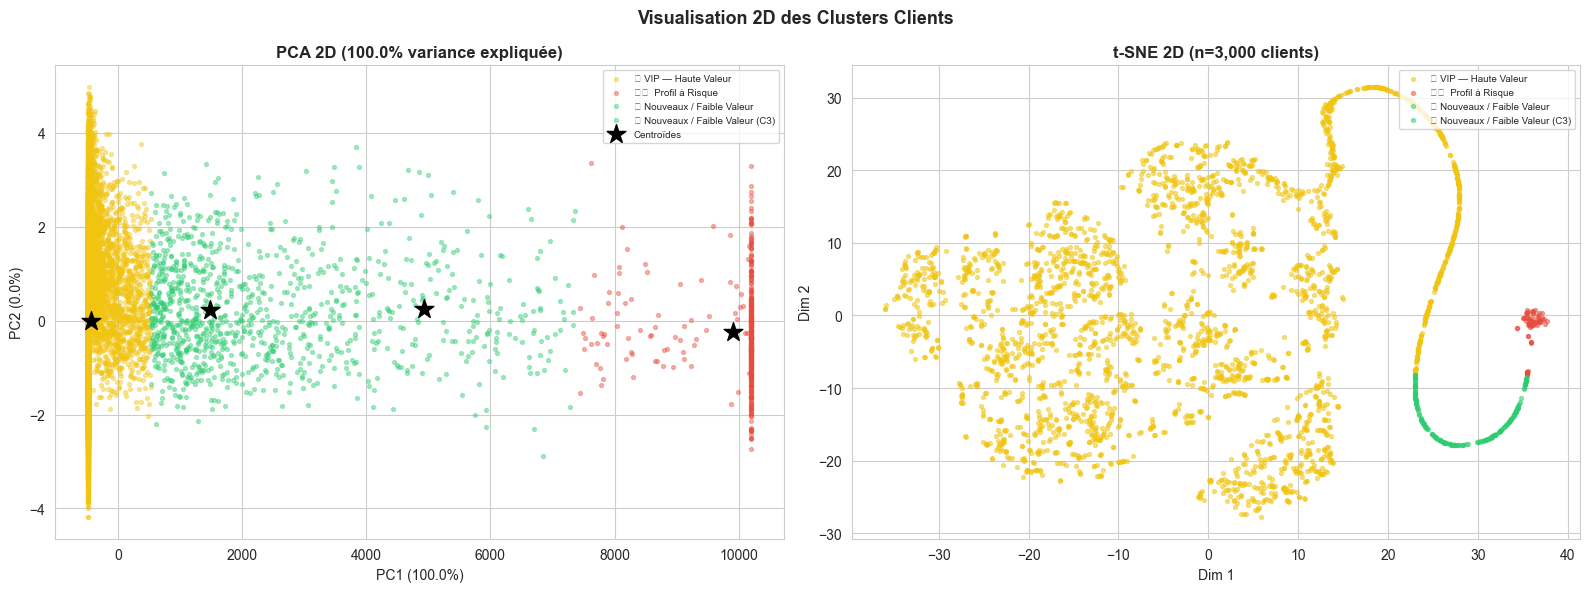

In [308]:
# PCA 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA
for c in sorted(master['CLUSTER'].unique()):
    mask = master['CLUSTER'] == c
    axes[0].scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        s=8, alpha=0.4, color=cluster_colors[c],
        label=cluster_names[c]
    )
# Centroïdes
centers_pca = pca.transform(kmeans.cluster_centers_)
axes[0].scatter(centers_pca[:, 0], centers_pca[:, 1],
               s=200, marker='*', c='black', zorder=5, label='Centroïdes')
axes[0].set_title(f'PCA 2D ({pca.explained_variance_ratio_.sum()*100:.1f}% variance expliquée)',
                  fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend(fontsize=7, loc='upper right')

# t-SNE (FIX : max_iter au lieu de n_iter)
N_TSNE = min(3000, len(X_scaled))
idx_sample = np.random.choice(len(X_scaled), N_TSNE, replace=False)
tsne = TSNE(n_components=2, perplexity=40, random_state=42, max_iter=500)
X_tsne = tsne.fit_transform(X_scaled[idx_sample])
labels_sample = master['CLUSTER'].values[idx_sample]

for c in sorted(np.unique(labels_sample)):
    mask = labels_sample == c
    axes[1].scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        s=8, alpha=0.5, color=cluster_colors[c],
        label=cluster_names[c]
    )
axes[1].set_title(f't-SNE 2D (n={N_TSNE:,} clients)', fontweight='bold')
axes[1].set_xlabel('Dim 1'); axes[1].set_ylabel('Dim 2')
axes[1].legend(fontsize=7, loc='upper right')

plt.suptitle('Visualisation 2D des Clusters Clients', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 10. Analyse Croisée Clusters × RFM

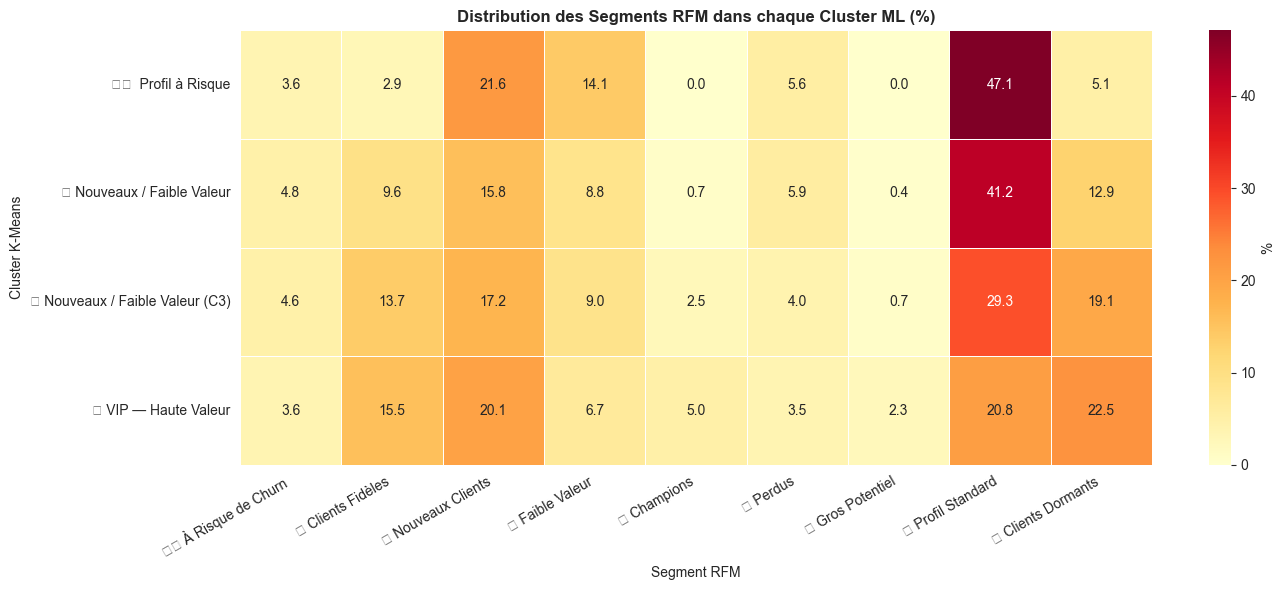

In [309]:
cross = pd.crosstab(
    master['CLUSTER_NOM'],
    master['RFM_SEGMENT'],
    normalize='index'
) * 100

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(cross, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': '%'})
ax.set_title('Distribution des Segments RFM dans chaque Cluster ML (%)',
             fontweight='bold')
ax.set_xlabel('Segment RFM'); ax.set_ylabel('Cluster K-Means')
plt.xticks(rotation=30, ha='right')
plt.tight_layout(); plt.show()

## 11. Valeur Client par Segment — CLV Simplifié
> FIX : CLV calculé sur données originales (non log), avant groupby.

In [310]:
# CLV approximatif = Primes annuelles × 3 ans × (1 - S/P) × (1 - Taux impayé)
# Utilise TOTAL_PRIMES original (non log-transformé) depuis master
master['PRIME_ANNUELLE'] = master['TOTAL_PRIMES'] / (master['ANCIENNETE_JOURS'].clip(30) / 365.25)

master['CLV_ESTIME'] = (
    master['PRIME_ANNUELLE'].fillna(0)
    * 3                                              # horizon 3 ans
    * (1 - master['TAUX_RESILIATION'].clip(0, 1).fillna(0.13))  # rétention
    * (1 - master['SP_RATIO'].clip(0, 1).fillna(0))             # profitabilité
    * (1 - master['TAUX_IMPAYE'].clip(0, 1).fillna(0))          # paiement
).clip(0)

clv_seg = master.groupby('CLUSTER_NOM').agg(
    NB_CLIENTS    = ('ID_CLIENT',      'count'),
    CLV_MOY       = ('CLV_ESTIME',     'mean'),
    CLV_TOTAL     = ('CLV_ESTIME',     'sum'),
    CLV_MEDIAN    = ('CLV_ESTIME',     'median'),
    PRIME_ANN_MOY = ('PRIME_ANNUELLE', 'mean'),
).sort_values('CLV_TOTAL', ascending=False).round(0)

clv_seg['PART_VALEUR_%'] = (clv_seg['CLV_TOTAL'] / clv_seg['CLV_TOTAL'].sum() * 100).round(1)

display(clv_seg.style
    .background_gradient(subset=['CLV_MOY','CLV_TOTAL'], cmap='Greens')
    .format({
        'CLV_MOY':       '{:,.0f}',
        'CLV_TOTAL':     '{:,.0f}',
        'CLV_MEDIAN':    '{:,.0f}',
        'PRIME_ANN_MOY': '{:,.0f}',
        'PART_VALEUR_%': '{:.1f}%',
    })
    .set_caption('Customer Lifetime Value Estimée par Segment')
)

# Sunburst CLV
fig = px.sunburst(
    clv_seg.reset_index(),
    path=['CLUSTER_NOM'],
    values='CLV_TOTAL',
    title='💰 Répartition de la Valeur Totale par Segment',
    color='CLV_MOY',
    color_continuous_scale='YlGn'
)
fig.update_layout(height=500)
fig.show()

,NB_CLIENTS,CLV_MOY,CLV_TOTAL,CLV_MEDIAN,PRIME_ANN_MOY,PART_VALEUR_%
CLUSTER_NOM,,,,,,
🏆 VIP — Haute Valeur,15082,"28,517","430,094,036","1,402","11,722",100.0%
🆕 Nouveaux / Faible Valeur (C3),758,3,"2,098",0,697,0.0%
⚠️ Profil à Risque,412,0,0,0,284,0.0%
🆕 Nouveaux / Faible Valeur,272,0,0,0,485,0.0%


## 12. Dashboard Final — Portrait de chaque Segment

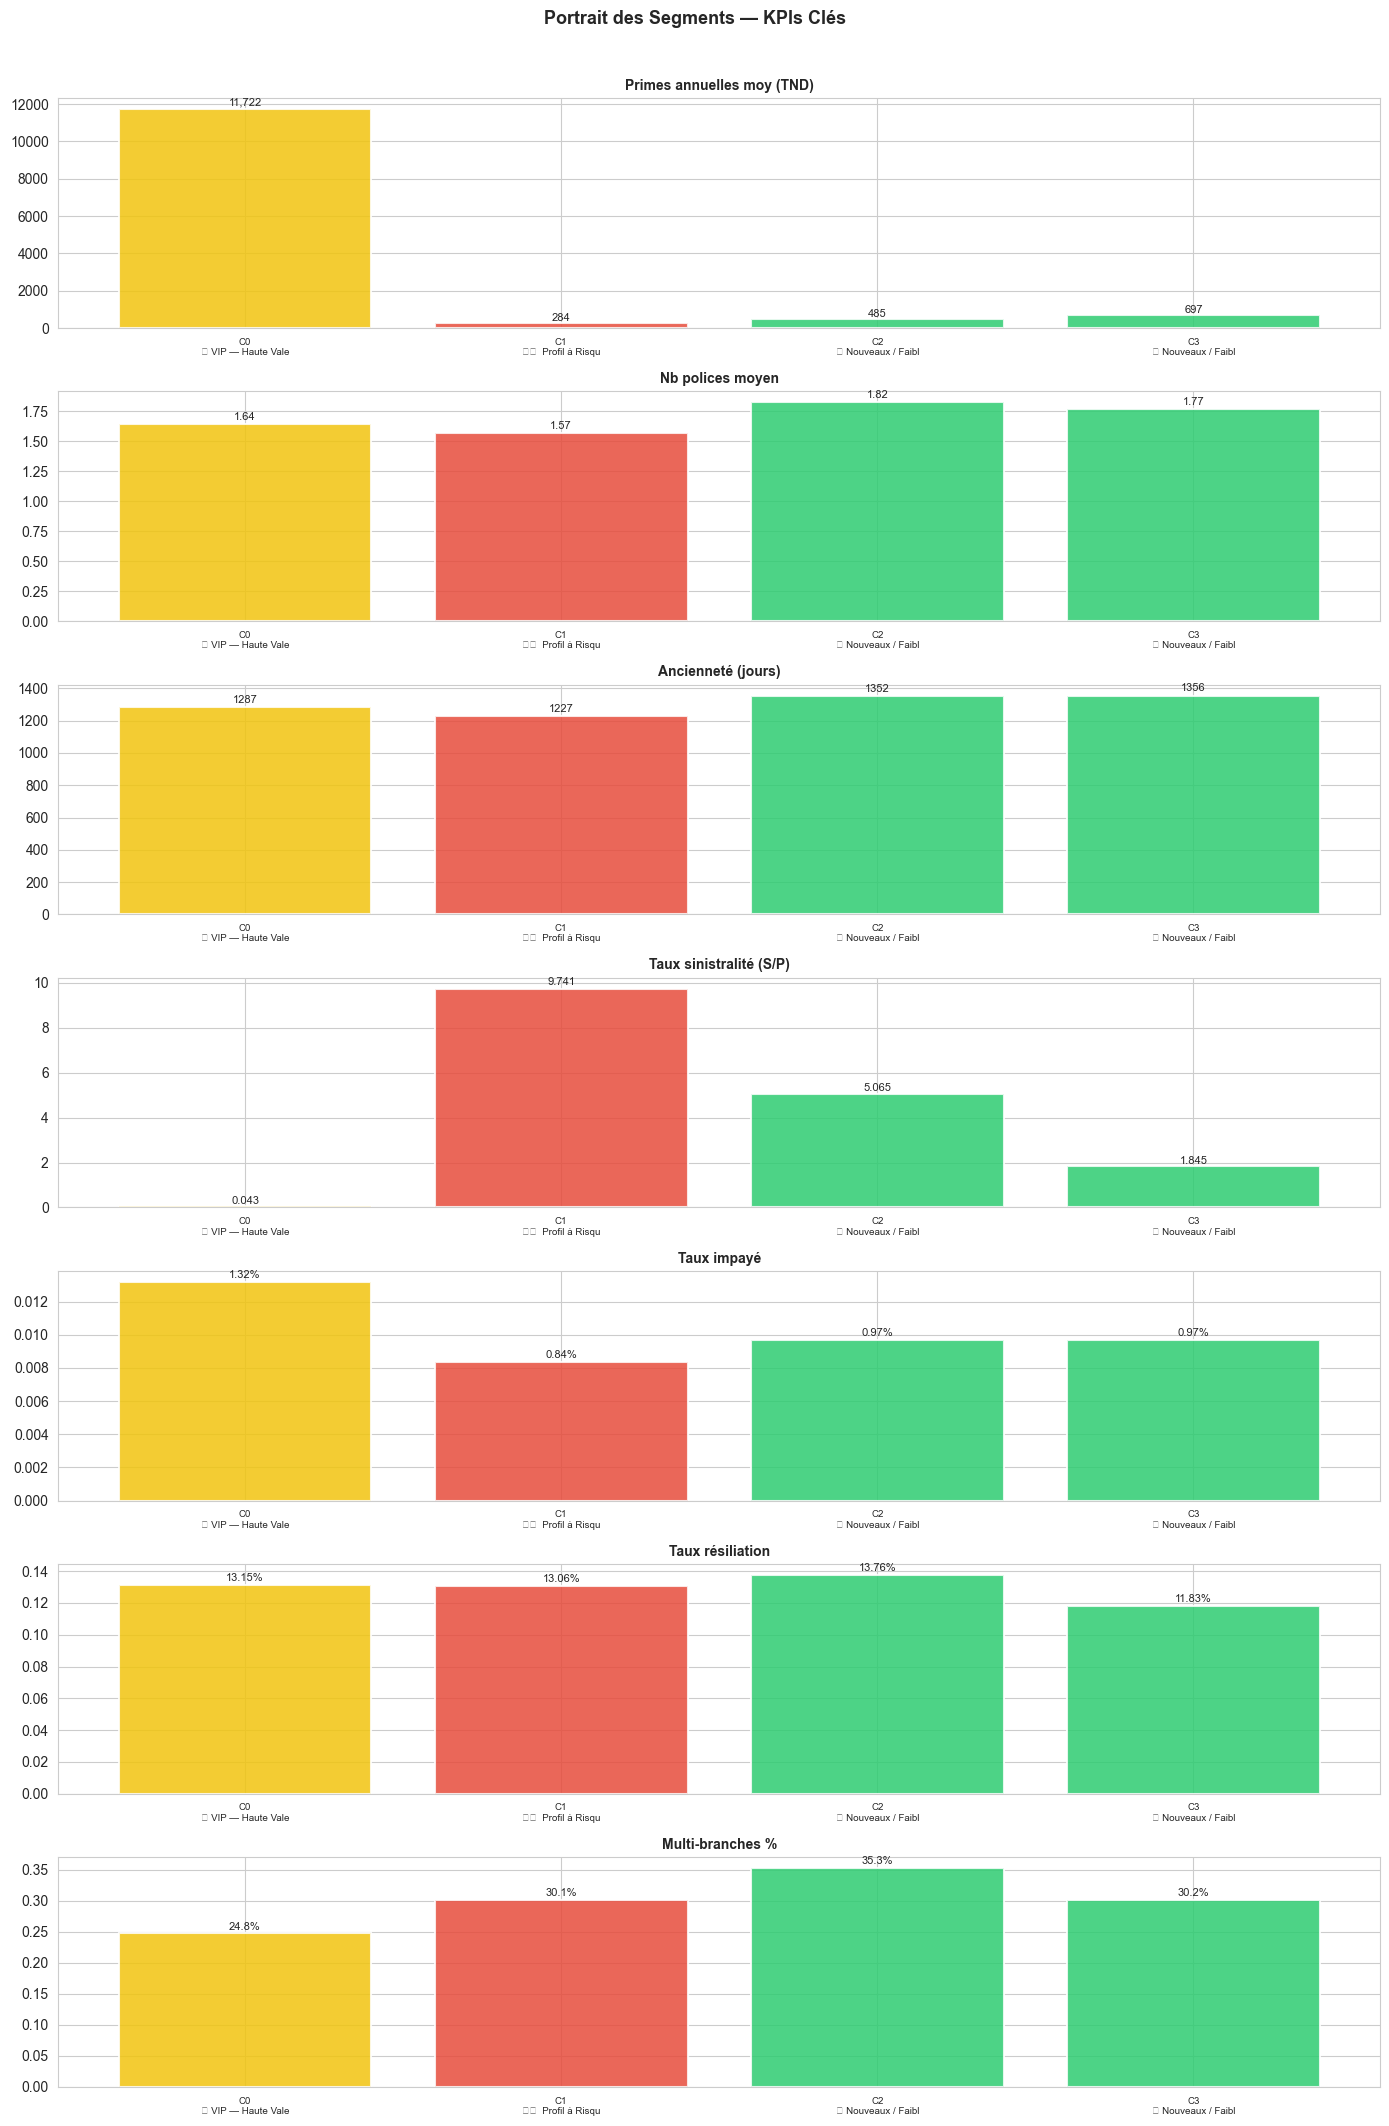

In [311]:
kpis = [
    ('Primes annuelles moy (TND)', 'PRIME_ANNUELLE',    '{:,.0f}'),
    ('Nb polices moyen',           'NB_POLICES',         '{:.2f}'),
    ('Ancienneté (jours)',         'ANCIENNETE_JOURS',   '{:.0f}'),
    ('Taux sinistralité (S/P)',    'SP_RATIO',           '{:.3f}'),
    ('Taux impayé',                'TAUX_IMPAYE',        '{:.2%}'),
    ('Taux résiliation',           'TAUX_RESILIATION',   '{:.2%}'),
    ('Multi-branches %',           'FLAG_MULTI_BRANCHES','{:.1%}'),
]

n_clusters = master['CLUSTER'].nunique()
fig, axes = plt.subplots(len(kpis), 1, figsize=(14, 3 * len(kpis)))

for ax, (label, col, fmt) in zip(axes, kpis):
    vals  = []
    names = []
    cols  = []
    for c in sorted(master['CLUSTER'].unique()):
        v = master[master['CLUSTER'] == c][col].mean()
        vals.append(v)
        names.append(f'C{c}\n{cluster_names[c][:18]}')
        cols.append(cluster_colors[c])
    bars = ax.bar(names, vals, color=cols, alpha=0.85, edgecolor='white', linewidth=1.5)
    ax.set_title(label, fontweight='bold', fontsize=10)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                fmt.format(v), ha='center', va='bottom', fontsize=8)
    ax.tick_params(axis='x', labelsize=7)

plt.suptitle('Portrait des Segments — KPIs Clés', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

## 13. Plan d'Actions CRM par Segment

In [312]:
ACTION_PLAN = {
    '🏆 VIP — Haute Valeur': {
        'Priorité'        : '🔴 MAXIMALE',
        'Objectif'        : 'Rétention & Cross-sell',
        'Actions'         : [
            'Gestionnaire dédié + appel personnalisé à chaque renouvellement',
            'Offre fidélité : remise 5–10% ou garanties gratuites',
            'Proposer extension multi-produits (auto + habitation + santé)',
            'Invitation événements compagnie',
        ],
        'Fréquence contact': 'Mensuelle',
        'Canal'            : 'Téléphone + Courrier premium',
    },
    '🏢 Entreprises / Flottes': {
        'Priorité'        : '🔴 MAXIMALE',
        'Objectif'        : 'Contrats cadre & Upsell',
        'Actions'         : [
            'Contrat cadre annuel avec revue trimestrielle',
            'Rapport sinistralité personnalisé (tableau de bord flotte)',
            'Tarification groupe + franchise adaptée',
            'Proposer assurance responsabilité professionnelle',
        ],
        'Fréquence contact': 'Trimestrielle',
        'Canal'            : 'Réunion en agence + Account Manager',
    },
    '⭐ Clients Fidèles': {
        'Priorité'        : '🟠 HAUTE',
        'Objectif'        : 'Cross-sell & Augmentation valeur',
        'Actions'         : [
            'Programme de fidélité : points par année sans sinistre',
            'Offre cross-sell basée sur profil (modèle recommendation)',
            'Communication anniversaire contrat',
        ],
        'Fréquence contact': 'Semestrielle',
        'Canal'            : 'Email + SMS + Application',
    },
    '😴 Dormants à Forte Valeur': {
        'Priorité'        : '🟠 HAUTE',
        'Objectif'        : 'Réactivation urgente',
        'Actions'         : [
            'Campagne de réactivation ciblée J-60 avant résiliation probable',
            'Enquête satisfaction : identifier la raison du désengagement',
            'Offre de retour : tarif préférentiel ou garantie supplémentaire',
            'Appel agent dans les 30 jours',
        ],
        'Fréquence contact': 'Immédiate puis mensuelle',
        'Canal'            : 'Appel + Email personnalisé',
    },
    '🆕 Nouveaux / Faible Valeur': {
        'Priorité'        : '🟡 MOYENNE',
        'Objectif'        : 'Onboarding & Montée en valeur',
        'Actions'         : [
            'Parcours onboarding digital : explication des garanties',
            'Proposer 2ème produit à 6 mois (probabilité cross-sell élevée)',
            'Rappel préventif avant 1er renouvellement',
            'Vérifier couverture adaptée au profil réel',
        ],
        'Fréquence contact': 'J+30, J+90, J+180',
        'Canal'            : 'Digital (email, app) + SMS',
    },
    '⚠️  Profil à Risque': {
        'Priorité'        : '🟡 MOYENNE (surveillance)',
        'Objectif'        : 'Réduction risque & Tarification correcte',
        'Actions'         : [
            'Révision tarifaire au renouvellement (Risk Score → surprime)',
            'Proposer prélèvement automatique (réduire le risque impayé)',
            'Vérifier éligibilité au renouvellement si S/P > 150%',
            'Monitoring sinistres accru',
        ],
        'Fréquence contact': 'Au renouvellement uniquement',
        'Canal'            : 'Courrier recommandé + Appel',
    },
    '📊 Standard / Intermédiaire': {
        'Priorité'        : '🟢 STANDARD',
        'Objectif'        : 'Satisfaction & Upsell ponctuel',
        'Actions'         : [
            'Communication annuelle satisfaction',
            'Newsletter produits nouveaux',
            'Offre anniversaire contrat',
        ],
        'Fréquence contact': 'Annuelle',
        'Canal'            : 'Email + Application mobile',
    },
}

def get_plan(nom):
    """Trouve le plan d'action en ignorant les suffixes de déduplication (C0, C1...)."""
    if nom in ACTION_PLAN:
        return ACTION_PLAN[nom]
    for key in ACTION_PLAN:
        if nom.startswith(key):
            return ACTION_PLAN[key]
    return ACTION_PLAN['📊 Standard / Intermédiaire']

clusters_presents = master['CLUSTER_NOM'].dropna().unique()
print('═' * 70)
for nom in sorted(clusters_presents):
    plan = get_plan(nom)
    n_clients = (master['CLUSTER_NOM'] == nom).sum()
    print(f'\n{nom}  ({n_clients:,} clients)')
    print(f'  Priorité         : {plan["Priorité"]}')
    print(f'  Objectif         : {plan["Objectif"]}')
    print(f'  Fréquence contact: {plan["Fréquence contact"]}')
    print(f'  Canal            : {plan["Canal"]}')
    print('  Actions :')
    for a in plan['Actions']:
        print(f'    → {a}')
print('\n' + '═' * 70)

══════════════════════════════════════════════════════════════════════

⚠️  Profil à Risque  (412 clients)
  Priorité         : 🟡 MOYENNE (surveillance)
  Objectif         : Réduction risque & Tarification correcte
  Fréquence contact: Au renouvellement uniquement
  Canal            : Courrier recommandé + Appel
  Actions :
    → Révision tarifaire au renouvellement (Risk Score → surprime)
    → Proposer prélèvement automatique (réduire le risque impayé)
    → Vérifier éligibilité au renouvellement si S/P > 150%
    → Monitoring sinistres accru

🆕 Nouveaux / Faible Valeur  (272 clients)
  Priorité         : 🟡 MOYENNE
  Objectif         : Onboarding & Montée en valeur
  Fréquence contact: J+30, J+90, J+180
  Canal            : Digital (email, app) + SMS
  Actions :
    → Parcours onboarding digital : explication des garanties
    → Proposer 2ème produit à 6 mois (probabilité cross-sell élevée)
    → Rappel préventif avant 1er renouvellement
    → Vérifier couverture adaptée au profil ré

## 14. Segment d'un Nouveau Client
> FIX : log-transform cohérent + normalisation de la confiance.

In [313]:
def segment_nouveau_client(client_features: dict) -> dict:
    """
    Attribue un segment à un nouveau client ou à un client existant mis à jour.

    Paramètres :
    - client_features : dict avec les valeurs des features (valeurs manquantes → médiane portefeuille)

    Retourne :
    - dict avec cluster, nom, confiance (%), et actions recommandées
    """
    # Base : médiane du portefeuille sur données originales
    row = master[CLUSTER_FEATURES].median().copy()

    # Surcharger avec les valeurs fournies
    for k, v in client_features.items():
        if k in row.index:
            row[k] = v

    # Appliquer le même pré-traitement que l'entraînement
    # 1. Cap outliers (utiliser les percentiles du portefeuille)
    for col in CLUSTER_FEATURES:
        p99 = master[col].quantile(0.99)
        p01 = master[col].quantile(0.01)
        row[col] = np.clip(row[col], p01, p99)

    # 2. Log-transform
    for col in LOG_COLS:
        if col in row.index:
            row[col] = np.log1p(row[col])

    # Prédiction
    X_new = scaler.transform(row.values.reshape(1, -1))
    cluster_id   = int(kmeans.predict(X_new)[0])
    cluster_name = cluster_names[cluster_id]

    # FIX : Confiance normalisée par distance moyenne intra-cluster
    center   = kmeans.cluster_centers_[cluster_id]
    dist     = np.linalg.norm(X_new - center)
    mask_c   = master['CLUSTER'] == cluster_id
    X_members = scaler.transform(
        master.loc[mask_c, CLUSTER_FEATURES]
        .fillna(0)
        .apply(lambda s: np.clip(s, master[s.name].quantile(0.01), master[s.name].quantile(0.99)))
        .apply(lambda s: np.log1p(s) if s.name in LOG_COLS else s)
    )
    avg_dist  = np.mean(np.linalg.norm(X_members - center, axis=1))
    confiance = max(0, min(100, (1 - dist / (avg_dist * 2 + 1e-9)) * 100))

    plan = get_plan(cluster_name)

    return {
        'Cluster'          : cluster_id,
        'Segment'          : cluster_name,
        'Confiance (%)'    : f'{confiance:.0f}%',
        'Priorité'         : plan['Priorité'],
        'Objectif CRM'     : plan['Objectif'],
        'Canal recommandé' : plan['Canal'],
        'Actions (top 2)'  : ' | '.join(plan['Actions'][:2]),
    }


# ── Exemples
print('═'*65)
print('CLIENT A — Ancien client multi-polices, peu de sinistres')
print('═'*65)
r1 = segment_nouveau_client({
    'RECENCY_DAYS'    : 30,
    'NB_POLICES'      : 3,
    'TOTAL_PRIMES'    : 8000,
    'ANCIENNETE_JOURS': 1800,
    'NB_SINISTRES'    : 1,
    'SP_RATIO'        : 0.1,
    'TAUX_IMPAYE'     : 0,
    'NB_BRANCHES'     : 2,
    'BONUS_MALUS_MOY' : 4,
})
for k, v in r1.items(): print(f'  {k:25s}: {v}')

print()
print('═'*65)
print('CLIENT B — Nouveau client, 1 police, impayé passé')
print('═'*65)
r2 = segment_nouveau_client({
    'RECENCY_DAYS'    : 15,
    'NB_POLICES'      : 1,
    'TOTAL_PRIMES'    : 500,
    'ANCIENNETE_JOURS': 120,
    'NB_SINISTRES'    : 0,
    'SP_RATIO'        : 0,
    'TAUX_IMPAYE'     : 0.5,
    'NB_BRANCHES'     : 1,
    'BONUS_MALUS_MOY' : 7,
})
for k, v in r2.items(): print(f'  {k:25s}: {v}')

═════════════════════════════════════════════════════════════════
CLIENT A — Ancien client multi-polices, peu de sinistres
═════════════════════════════════════════════════════════════════
  Cluster                  : 0
  Segment                  : 🏆 VIP — Haute Valeur
  Confiance (%)            : 61%
  Priorité                 : 🔴 MAXIMALE
  Objectif CRM             : Rétention & Cross-sell
  Canal recommandé         : Téléphone + Courrier premium
  Actions (top 2)          : Gestionnaire dédié + appel personnalisé à chaque renouvellement | Offre fidélité : remise 5–10% ou garanties gratuites

═════════════════════════════════════════════════════════════════
CLIENT B — Nouveau client, 1 police, impayé passé
═════════════════════════════════════════════════════════════════
  Cluster                  : 0
  Segment                  : 🏆 VIP — Haute Valeur
  Confiance (%)            : 71%
  Priorité                 : 🔴 MAXIMALE
  Objectif CRM             : Rétention & Cross-sell
  Canal re

## 15. Export

In [314]:
import pickle

# Sauvegarder le modèle
artifacts = {
    'kmeans'          : kmeans,
    'scaler'          : scaler,
    'cluster_features': CLUSTER_FEATURES,
    'log_cols'        : LOG_COLS,
    'cluster_names'   : cluster_names,
    'cluster_colors'  : cluster_colors,
    'action_plan'     : ACTION_PLAN,
    'segment_fn'      : segment_nouveau_client,
}
with open('segmentation_model.pkl', 'wb') as f:
    pickle.dump(artifacts, f)
print('✅ Modèle sauvegardé : segmentation_model.pkl')

# Export Excel
out_cols = [
    'ID_CLIENT','RECENCY_DAYS','NB_POLICES','TOTAL_PRIMES','PRIME_ANNUELLE',
    'ANCIENNETE_JOURS','NB_SINISTRES','SP_RATIO','TAUX_IMPAYE','TAUX_RESILIATION',
    'NB_BRANCHES','BONUS_MALUS_MOY','FLAG_MORALE',
    'R_SCORE','F_SCORE','M_SCORE','RFM_SEGMENT',
    'CLUSTER','CLUSTER_NOM','CLV_ESTIME'
]
out_cols = [c for c in out_cols if c in master.columns]


✅ Modèle sauvegardé : segmentation_model.pkl
